# 🧠 EEG Motor Imagery Brain-Computer Interface for Stroke Rehabilitation
## Complete Pipeline: Signal Processing → Feature Extraction → Classification → Virtual Arm Control

**Clinical goal:** Decode motor imagery from EEG to drive a virtual arm for stroke rehabilitation,
leveraging neuroplasticity through action observation and embodiment via the mirror neuron system.

**Pipeline:** EEG → Preprocessing → Feature Extraction → Classifier → Prediction → Unity Virtual Arm

---

## Section 0 — Environment Setup

Install all required packages and configure the runtime environment.
We pin seeds everywhere and suppress verbose logs for clean execution.

In [1]:
# ============================================================
# SECTION 0 — Install required packages
# ============================================================
# Install scientific/ML stack needed for BCI pipeline
# moabb: Mother Of All BCI Benchmarks — standardized BCI dataset loading
# mne: EEG/MEG analysis library (filtering, ICA, epochs, topomaps)
# torch: deep learning framework (used in later sections)
# seaborn: statistical visualization built on matplotlib

import subprocess, sys

packages = [
    'moabb', 'mne', 'numpy', 'matplotlib', 'scipy',
    'scikit-learn', 'torch', 'seaborn', 'pandas'
]

for pkg in packages:
    try:
        __import__(pkg if pkg != 'scikit-learn' else 'sklearn')
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

print("All packages installed / available.")

All packages installed / available.


In [2]:
# ============================================================
# SECTION 0 — Imports (organized by group)
# ============================================================

# --- Standard library ---
import os               # File path manipulation
import sys              # System info (Python version)
import warnings         # Suppress non-critical warnings
import random           # Python built-in random seed
import json             # JSON export for Unity integration
from pathlib import Path  # Object-oriented filesystem paths
from collections import Counter  # Count annotation types

# --- Numerical / scientific ---
import numpy as np                           # Array operations
from scipy.signal import hilbert             # Analytic signal for instantaneous power
from scipy.stats import zscore               # Z-score normalization

# --- Visualization ---
import matplotlib
import matplotlib.pyplot as plt              # Core plotting
import matplotlib.patches as mpatches        # Custom legend patches
from matplotlib.colors import TwoSlopeNorm   # Diverging colormaps centered at 0
import seaborn as sns                        # Statistical plots (heatmaps, etc.)
import pandas as pd                          # Tabular data display

# --- Machine Learning ---
import sklearn
from sklearn.pipeline import Pipeline                    # Chain transformers + classifier
from sklearn.svm import SVC                              # Support Vector Classifier
from sklearn.model_selection import (
    StratifiedKFold,        # Stratified outer CV
    GridSearchCV,           # Inner CV for hyperparameter tuning
    cross_val_predict       # For confusion matrix from CV
)
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,  # Performance metrics
    confusion_matrix, roc_curve, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler  # Feature scaling

# --- EEG / BCI ---
import mne                                    # EEG processing
from mne.decoding import CSP                  # Common Spatial Patterns

# MOABB — standardized BCI dataset access
from moabb.datasets import BNCI2014_001       # BCI Competition IV 2a
from moabb.paradigms import LeftRightImagery   # Left vs right MI paradigm

# --- Deep Learning ---
import torch                                  # PyTorch tensors & models
import torch.nn as nn                         # Neural network layers
import torch.optim as optim                   # Optimizers

# ============================================================
# SECTION 0 — Random seeds & configuration
# ============================================================
SEED = 42
np.random.seed(SEED)          # NumPy reproducibility
random.seed(SEED)             # Python stdlib reproducibility
torch.manual_seed(SEED)       # PyTorch CPU reproducibility
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)  # PyTorch GPU reproducibility

# Suppress non-critical warnings to keep output clean
warnings.filterwarnings('ignore')
# Set MNE log level to WARNING — suppress INFO messages during processing
mne.set_log_level('WARNING')

# Detect GPU availability for later deep-learning sections
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Create output directory for saved figures
os.makedirs('figures', exist_ok=True)

# Print environment info for reproducibility
print(f"Python      : {sys.version.split()[0]}")
print(f"NumPy       : {np.__version__}")
print(f"SciPy       : {__import__('scipy').__version__}")
print(f"Matplotlib  : {matplotlib.__version__}")
print(f"Seaborn     : {sns.__version__}")
print(f"Pandas      : {pd.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")
print(f"MNE         : {mne.__version__}")
print(f"PyTorch     : {torch.__version__}")
print(f"Device      : {device}")
print()
print("✅ Section 0 complete — environment ready")

Python      : 3.13.0
NumPy       : 2.2.0
SciPy       : 1.17.1
Matplotlib  : 3.9.3
Seaborn     : 0.13.2
Pandas      : 2.2.3
Scikit-learn: 1.8.0
MNE         : 1.12.0
PyTorch     : 2.11.0+cpu
Device      : cpu

✅ Section 0 complete — environment ready


---
## Section 1 — Loading the Schalk Dataset (PhysioNet Motor Movement/Imagery)

### 🧠 Motor Imagery Physiology

**Motor imagery** (MI) is the mental rehearsal of a movement without physical execution.
Neuroimaging reveals that imagining a movement activates many of the same motor cortex
regions as actually performing it — in particular the **primary motor cortex (M1)** and
the **supplementary motor area (SMA)**.

#### Why does this work for stroke rehabilitation?
After a stroke that damages the motor cortex or corticospinal tract, patients may be
unable to move their affected limb. However, attempting motor imagery still activates
surviving motor circuits, and **repeated practice combined with visual feedback** (a
virtual arm mirroring the decoded intention) stimulates **neuroplasticity** — the brain's
ability to rewire itself — via the **mirror neuron system**.

#### Event-Related Desynchronization (ERD)
When a person imagines moving their right hand, neurons in the **left motor cortex**
(contralateral to the imagined hand) become active and **desynchronize**. This reduces
oscillatory power in the **mu rhythm (8–12 Hz)** and **beta rhythm (13–30 Hz)** bands
— a phenomenon called **ERD (Event-Related Desynchronization)**.

- **C3 electrode** (left motor cortex) → responds to **right-hand** MI
- **C4 electrode** (right motor cortex) → responds to **left-hand** MI

This contralateral ERD pattern is the primary signal our BCI will decode.

#### After the movement: Beta Rebound (ERS)
After the imagery period ends, there is a brief **increase** in beta power called
**Event-Related Synchronization (ERS)** or **beta rebound**, indicating the motor cortex
returning to its resting state.

In [3]:
# ============================================================
# SECTION 1 — Load Schalk dataset (subject S001, runs 4, 8, 12)
# ============================================================

def load_schalk_subject(subject_id=1, runs=(4, 8, 12), data_dir='./data/schalk'):
    """
    WHY: Load EEG data for one subject from the Schalk motor imagery dataset.
         We concatenate specific MI-only runs (4, 8, 12) that contain pure
         motor imagery without actual movement.
    WHAT: Read EDF files for specified runs, concatenate into a single Raw object.
    INPUT:
        subject_id : int — subject number (1–109)
        runs : tuple of int — run numbers to load (4, 8, 12 = MI runs)
        data_dir : str — root directory of the Schalk dataset in BIDS format
    OUTPUT:
        raw : mne.io.Raw — concatenated raw EEG data with annotations
    """
    # Build subject directory path (BIDS format: sub-001, sub-002, ...)
    sub_str = f'sub-{subject_id:03d}'  # Zero-padded 3-digit subject ID
    sub_dir = Path(data_dir) / sub_str / 'eeg'

    raws = []  # Collect Raw objects for each run

    for run in runs:
        # Schalk dataset file naming convention
        # Run numbering in filename: R04, R08, R12
        fname = sub_dir / f'{sub_str}_task-mi_run-{run:02d}_eeg.edf'

        # Fallback: try PhysioNet naming convention if BIDS naming fails
        if not fname.exists():
            # PhysioNet uses S001R04.edf format
            fname_alt = sub_dir / f'S{subject_id:03d}R{run:02d}.edf'
            if fname_alt.exists():
                fname = fname_alt
            else:
                # Try flat directory structure
                for candidate_dir in [
                    Path(data_dir) / sub_str,
                    Path(data_dir),
                    Path(data_dir) / 'files'
                ]:
                    fname_alt = candidate_dir / f'S{subject_id:03d}R{run:02d}.edf'
                    if fname_alt.exists():
                        fname = fname_alt
                        break

        if not fname.exists():
            print(f"⚠️  File not found: {fname}")
            print(f"    Trying MNE built-in PhysioNet download...")
            # Use MNE's built-in eegbci dataset fetcher as fallback
            # This downloads from PhysioNet automatically
            from mne.datasets import eegbci
            fnames = eegbci.load_data(subject_id, run, path=str(Path(data_dir).parent))
            fname = fnames[0]

        print(f"  Loading: {Path(fname).name}")
        # preload=True loads data into memory (needed for concatenation)
        raw_run = mne.io.read_raw_edf(str(fname), preload=True)
        raws.append(raw_run)

    # Concatenate all runs into one continuous Raw object
    # This preserves annotations (T0, T1, T2) from each run
    raw = mne.concatenate_raws(raws)

    # Standardize channel names to the 10-20 system
    # PhysioNet uses dots (e.g., 'Fc5.') — strip trailing dots
    mne.datasets.eegbci.standardize(raw)

    # Set the standard 10-05 montage for topographic plotting
    montage = mne.channels.make_standard_montage('standard_1005')
    raw.set_montage(montage, on_missing='warn')

    return raw

# Load subject 1 with motor imagery runs
print("Loading subject S001, runs 4, 8, 12 (motor imagery only)...")
raw = load_schalk_subject(subject_id=1, runs=[4, 8, 12])
print()

# --- Print dataset summary ---
print(f"Number of channels  : {len(raw.ch_names)}")
print(f"Sampling frequency  : {raw.info['sfreq']} Hz")
print(f"Total duration      : {raw.times[-1]:.1f} seconds ({raw.times[-1]/60:.1f} min)")
print(f"Channel names (first 10): {raw.ch_names[:10]}")
print()

# Count annotations (T0=rest, T1=left fist MI, T2=right fist MI)
ann_counts = Counter(raw.annotations.description)
print("Annotation counts:")
for desc, count in sorted(ann_counts.items()):
    label = {'T0': 'rest', 'T1': 'left fist MI', 'T2': 'right fist MI'}.get(desc, desc)
    print(f"  {desc} ({label}): {count}")

Loading subject S001, runs 4, 8, 12 (motor imagery only)...
⚠️  File not found: data\schalk\sub-001\eeg\sub-001_task-mi_run-04_eeg.edf
    Trying MNE built-in PhysioNet download...


  Loading: S001R04.edf
⚠️  File not found: data\schalk\sub-001\eeg\sub-001_task-mi_run-08_eeg.edf
    Trying MNE built-in PhysioNet download...


  Loading: S001R08.edf
⚠️  File not found: data\schalk\sub-001\eeg\sub-001_task-mi_run-12_eeg.edf
    Trying MNE built-in PhysioNet download...
  Loading: S001R12.edf

Number of channels  : 64
Sampling frequency  : 160.0 Hz
Total duration      : 375.0 seconds (6.2 min)
Channel names (first 10): ['FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6', 'C5', 'C3', 'C1']

Annotation counts:
  BAD boundary (BAD boundary): 2
  EDGE boundary (EDGE boundary): 2
  T0 (rest): 45
  T1 (left fist MI): 23
  T2 (right fist MI): 22


In [61]:
print(channel_names := raw.ch_names)

['FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP5', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'CP6', 'Fp1', 'Fpz', 'Fp2', 'AF7', 'AF3', 'AFz', 'AF4', 'AF8', 'F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8', 'FT7', 'FT8', 'T7', 'T8', 'T9', 'T10', 'TP7', 'TP8', 'P7', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'P8', 'PO7', 'PO3', 'POz', 'PO4', 'PO8', 'O1', 'Oz', 'O2', 'Iz']


In [4]:
# ============================================================
# SECTION 1 — Extract events from annotations
# ============================================================

# The Schalk/PhysioNet dataset uses annotations (not STIM channels).
# T0 = rest, T1 = left fist motor imagery, T2 = right fist motor imagery.
# MNE can convert these text annotations to numeric event arrays.

# Define mapping: annotation text → integer event code
event_id = {'T1': 1, 'T2': 2}  # We ignore T0 (rest) — not needed for binary classification

# Convert annotations to events array (n_events × 3: [sample, 0, event_code])
events, event_id_used = mne.events_from_annotations(raw, event_id=event_id)
print(f"Total MI events extracted: {len(events)}")
print(f"  T1 (left fist MI) : {np.sum(events[:, 2] == 1)}")
print(f"  T2 (right fist MI): {np.sum(events[:, 2] == 2)}")
print()
print("Event array shape:", events.shape)
print("First 5 events (sample, 0, event_code):")
print(events[:5])

Total MI events extracted: 45
  T1 (left fist MI) : 23
  T2 (right fist MI): 22

Event array shape: (45, 3)
First 5 events (sample, 0, event_code):
[[ 672    0    2]
 [2000    0    1]
 [3328    0    1]
 [4656    0    2]
 [5984    0    2]]


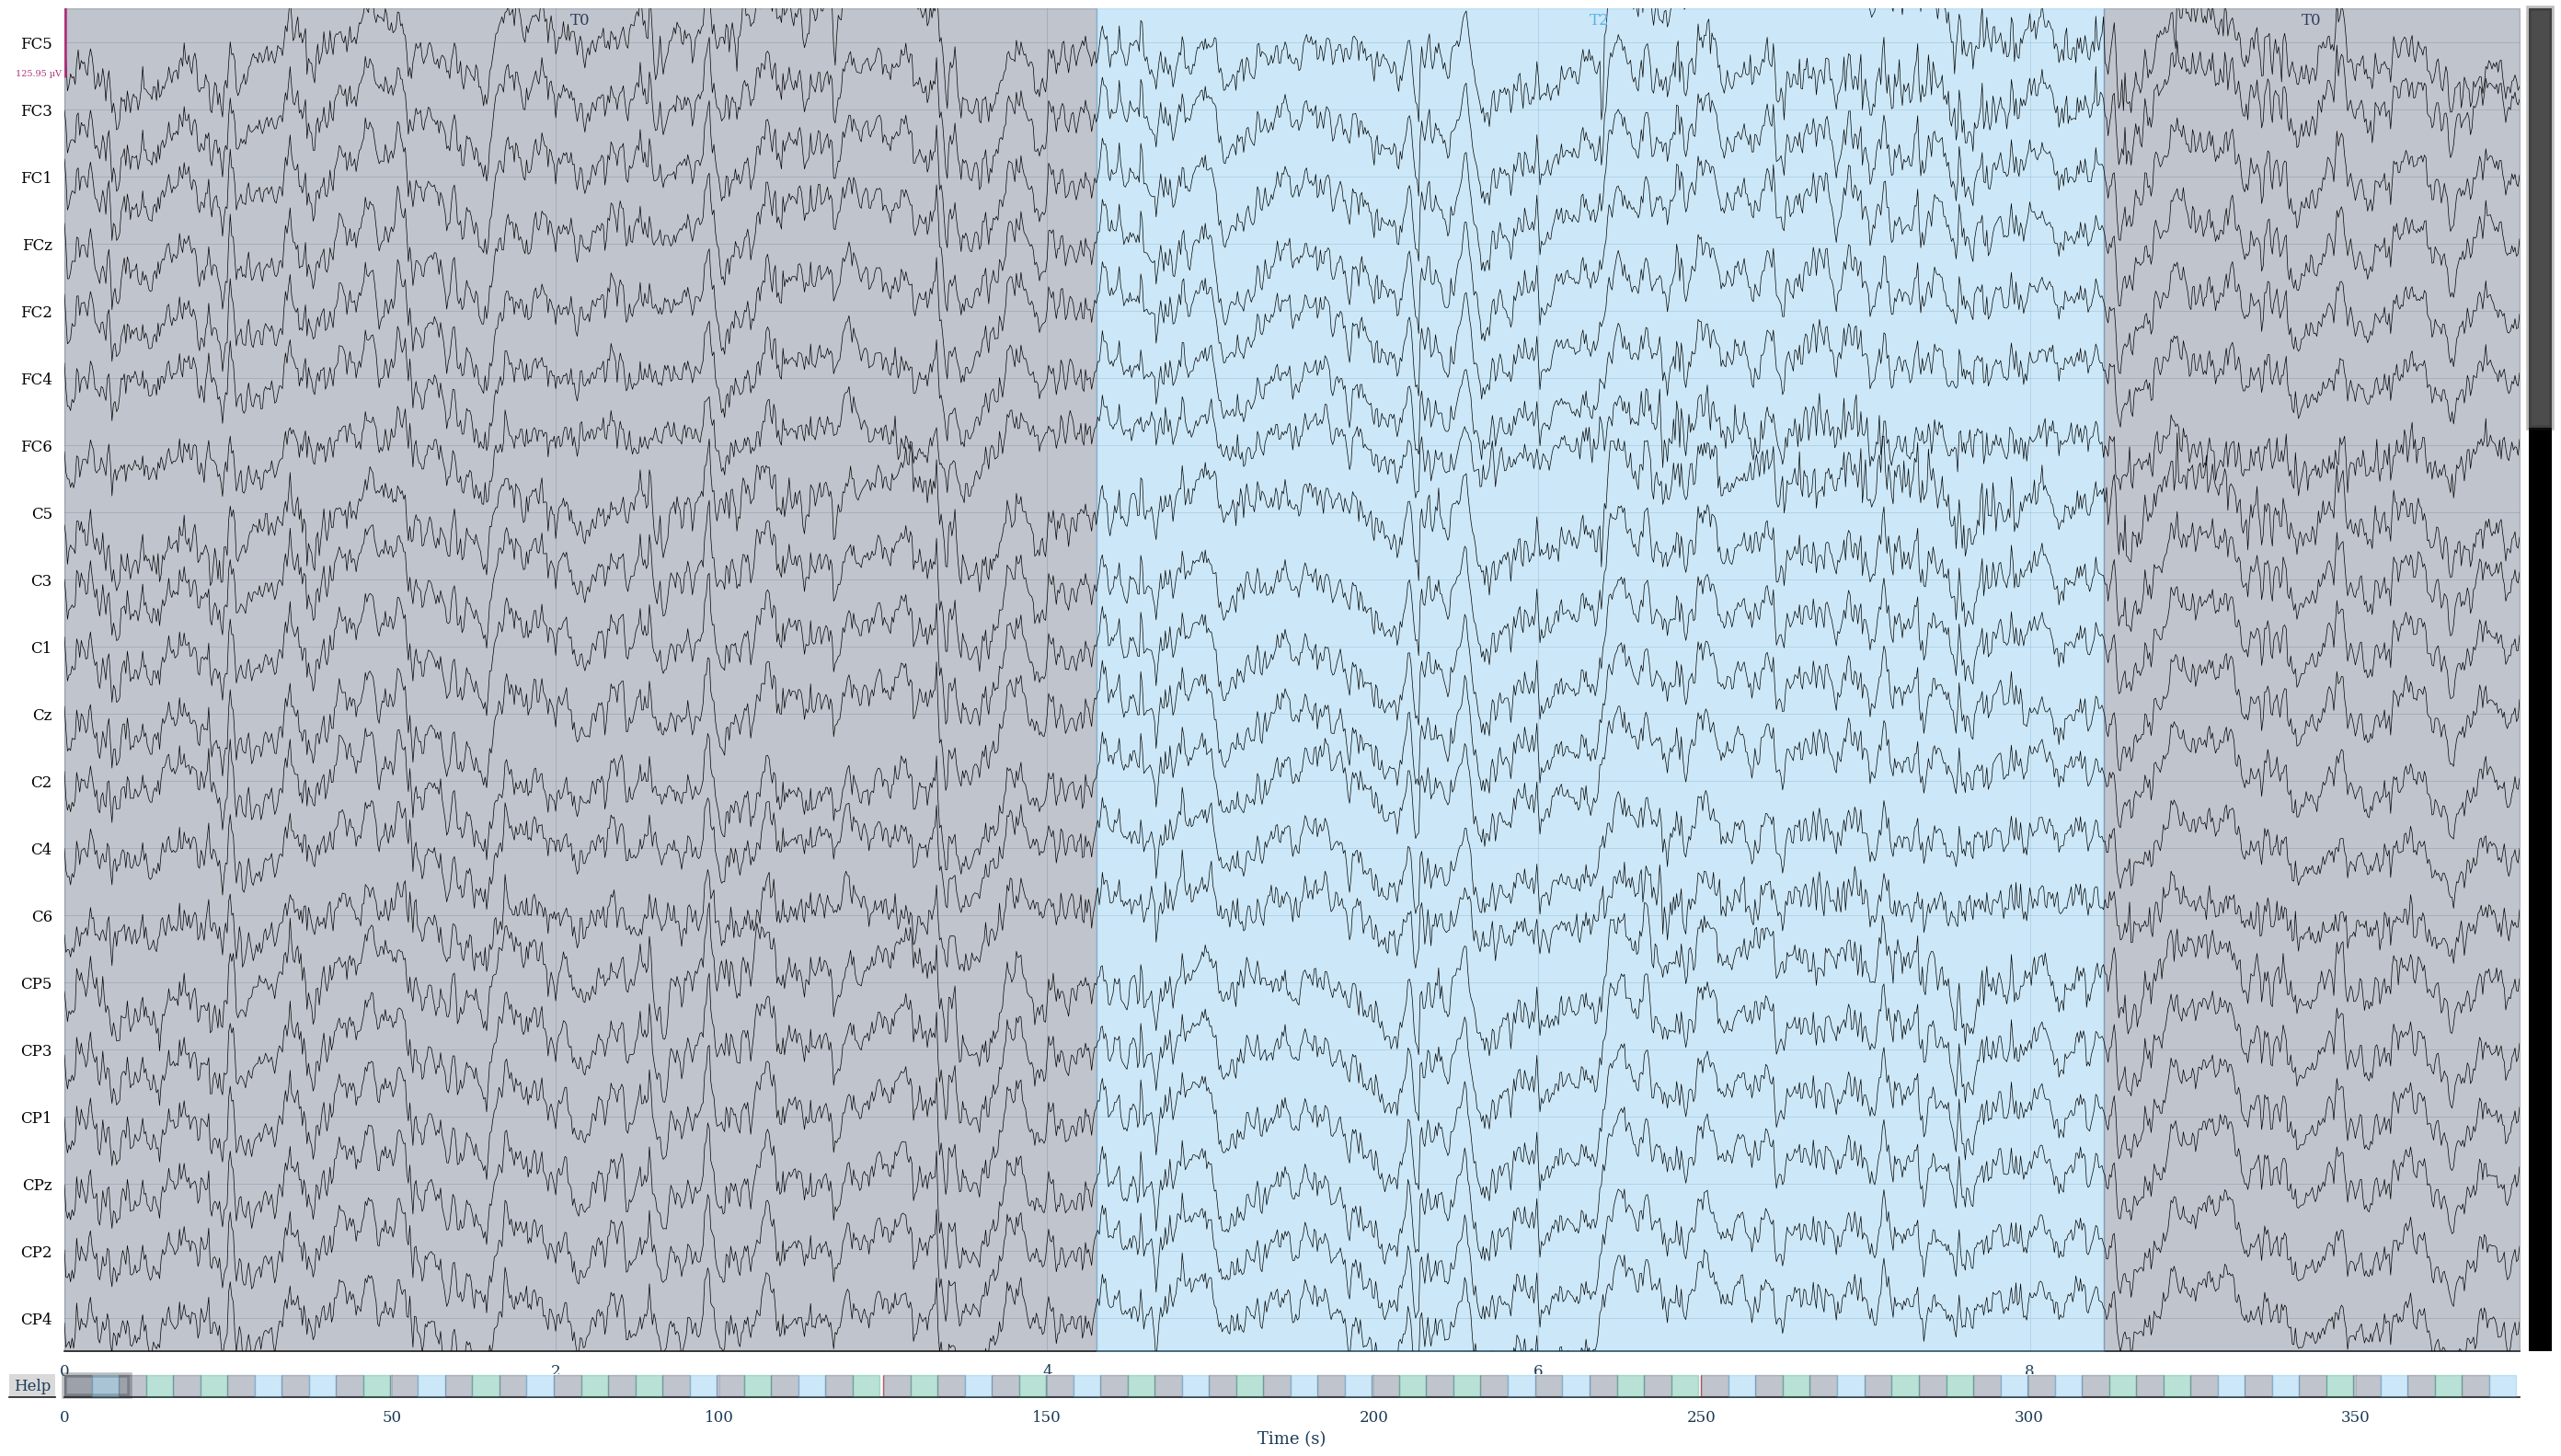

Saved: figures/section1_fig1_raw_eeg.png


In [43]:
# ============================================================
# SECTION 1 — Plot 10 seconds of raw EEG
# ============================================================

# Show raw EEG to visualize signal quality and amplitude range.
# We pick a window that includes some task events for context.
fig = raw.plot(
    duration=10,           # Show 10 seconds of data
    n_channels=20,         # Display 20 channels (avoid clutter)
    scalings='auto',       # Auto-scale channel amplitudes
    title='Raw EEG — Subject S001 (10s window)',
    show=False             # Don't display interactively (save instead)
)
fig.set_size_inches(28, 16)
plt.tight_layout()
plt.savefig('figures/section1_fig1_raw_eeg.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/section1_fig1_raw_eeg.png")

### 📊 What to look for in this plot:

- **Signal amplitude**: Typical EEG is 10–100 µV. Channels with very large amplitudes
  (>200 µV) may have artifacts (eye blinks, muscle tension, electrode pop).
- **50/60 Hz noise**: Look for a constant high-frequency buzz — this is power line
  interference that our bandpass filter will remove.
- **Channel consistency**: Most channels should have similar amplitude ranges. A flat
  line indicates a bad/disconnected electrode.
- **Event markers**: Vertical lines/annotations mark trial onsets (T1, T2). These help
  verify that our event extraction is correct.
- **Eye blinks**: Large slow deflections primarily visible in frontal channels (Fp1, Fp2)
  — these will be removed by ICA in Section 2.

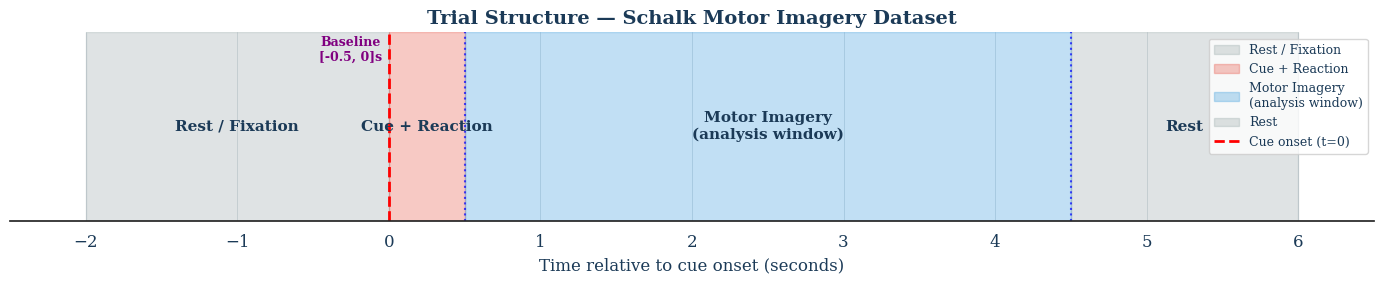

Saved: figures/section1_fig2_trial_structure.png


In [13]:
# ============================================================
# SECTION 1 — Trial structure diagram
# ============================================================

# The Schalk dataset has the following trial structure:
# [Rest ~4s] → [Cue onset at t=0] → [Motor imagery ~4s] → [Rest ~4s]
# T1/T2 annotations mark the cue onset.
# We will epoch from 0.5s to 4.5s post-cue (avoiding the initial reaction period).

fig, ax = plt.subplots(1, 1, figsize=(14, 3))

# Define trial phases with their time ranges and colors
phases = [
    (-2.0, 0.0, '#95a5a6', 'Rest / Fixation'),     # Gray — baseline rest
    (0.0, 0.5, '#e74c3c', 'Cue + Reaction'),        # Red — cue appears
    (0.5, 4.5, '#3498db', 'Motor Imagery\n(analysis window)'),  # Blue — MI period
    (4.5, 6.0, '#95a5a6', 'Rest'),                   # Gray — post-trial rest
]

for t_start, t_end, color, label in phases:
    # Draw colored rectangle for each trial phase
    ax.axvspan(t_start, t_end, alpha=0.3, color=color, label=label)
    # Add phase label centered in the rectangle
    ax.text((t_start + t_end) / 2, 0.5, label,
            ha='center', va='center', fontsize=11, fontweight='bold',
            transform=ax.get_xaxis_transform())

# Mark cue onset
ax.axvline(x=0, color='red', linewidth=2, linestyle='--', label='Cue onset (t=0)')

# Mark analysis window boundaries
ax.axvline(x=0.5, color='blue', linewidth=1.5, linestyle=':', alpha=0.7)
ax.axvline(x=4.5, color='blue', linewidth=1.5, linestyle=':', alpha=0.7)

# Annotate the baseline period used for ERD calculation
ax.annotate('Baseline\n[-0.5, 0]s', xy=(-0.25, 0.85),
            ha='center', fontsize=9, color='purple', fontweight='bold',
            transform=ax.get_xaxis_transform())

ax.set_xlim(-2.5, 6.5)
ax.set_xlabel('Time relative to cue onset (seconds)', fontsize=12)
ax.set_title('Trial Structure — Schalk Motor Imagery Dataset', fontsize=14, fontweight='bold')
ax.set_yticks([])  # No y-axis needed for this diagram

# Remove duplicate legend entries
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('figures/section1_fig2_trial_structure.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/section1_fig2_trial_structure.png")

### 📊 What to look for in this plot:

- **Timing of analysis window**: Our epoch window [0.5, 4.5]s avoids the initial 0.5s
  after cue onset, where the brain is processing the visual cue rather than performing
  motor imagery. This reduces contamination from visual evoked potentials.
- **Baseline period**: The [-0.5, 0]s pre-cue window captures the resting state used
  as reference for ERD/ERS calculations.
- **Rest periods**: Adequate rest between trials (~4s) allows the brain to return to
  baseline, preventing carry-over effects between trials.

In [ ]:
print("✅ Section 1 complete — Schalk dataset loaded, events extracted, trial structure visualized")

---
## Section 2 — Preprocessing Pipeline

### 🎛️ Signal Processing Analogies

Each preprocessing step has a real-world analogy:

| Step | Analogy | EEG Purpose |
|------|---------|-------------|
| **Bandpass filter (8–30 Hz)** | Audio equalizer cutting bass and treble | Keep only mu and beta rhythms; remove slow drift and high-frequency muscle noise |
| **Average reference** | Removing the shared background hum in a conference call | Eliminate contamination from the reference electrode; every channel now reflects local brain activity |
| **ICA (Independent Component Analysis)** | Unmixing a cocktail party recording to isolate each speaker | Separate eye blinks, heartbeat, and muscle artifacts from brain signals |
| **Epoching** | Cutting a long film into short labeled clips | Extract fixed-length segments around each event for analysis |

### 🌊 Key Frequency Bands

- **Mu rhythm (8–12 Hz)**: Dominant over sensorimotor cortex at rest. **Decreases (ERD)**
  when the person imagines or performs a movement — the motor cortex becomes "active" and
  desynchronized.
- **Beta rhythm (13–30 Hz)**: Also present over motor cortex. Shows ERD during motor
  imagery, followed by a brief **increase (ERS/beta rebound)** after the imagery ends.

Together, the 8–30 Hz bandpass captures both mu and beta ERD, which are the primary
features our BCI will decode.

In [64]:
# ============================================================
# SECTION 2 — Reusable preprocessing function
# ============================================================

def preprocess_raw(raw, sfreq_target=160, l_freq=8.0, h_freq=30.0,
                   n_ica_components=63, epoch_tmin=0.5, epoch_tmax=4.5,
                   baseline=(-0.5, 0.0), reject_uv=200e-6,
                   event_id=None):
    """
    WHY: Standardized preprocessing pipeline that works for both Schalk (160 Hz)
         and BCI Competition IV 2a (250 Hz) datasets. Ensures consistent feature
         extraction regardless of original sampling rate or reference scheme.
    WHAT: Resample → bandpass filter → re-reference → ICA artifact removal → epoch.
    INPUT:
        raw           : mne.io.Raw — raw EEG data (preloaded)
        sfreq_target  : float — target sampling rate in Hz (160 for Schalk)
        l_freq        : float — lower bandpass cutoff (8 Hz = mu band start)
        h_freq        : float — upper bandpass cutoff (30 Hz = beta band end)
        n_ica_components : int — number of ICA components to compute
        epoch_tmin    : float — epoch start relative to event onset (seconds)
        epoch_tmax    : float — epoch end relative to event onset (seconds)
        baseline      : tuple — baseline correction window (seconds)
        reject_uv     : float — peak-to-peak rejection threshold in volts
        event_id      : dict or None — event name→code mapping; default T1/T2
    OUTPUT:
        epochs : mne.Epochs — cleaned, epoched EEG data
    """
    import copy
    raw = raw.copy()  # Don't modify the original — preserve raw data for later comparison

    if event_id is None:
        event_id = {'T1': 1, 'T2': 2}  # Default: left/right fist MI

    # ------------------------------------------------------------------
    # Step 1: Resample to target frequency
    # ------------------------------------------------------------------
    # WHY: Nyquist theorem requires sfreq >= 2 * max_freq_of_interest.
    #      Our max frequency is 30 Hz, so 160 Hz is more than sufficient
    #      (160/2 = 80 Hz > 30 Hz). Lower sfreq = faster computation.
    current_sfreq = raw.info['sfreq']
    if abs(current_sfreq - sfreq_target) > 1.0:  # Only resample if significantly different
        print(f"  Resampling: {current_sfreq} Hz → {sfreq_target} Hz")
        raw.resample(sfreq_target)

    # ------------------------------------------------------------------
    # Step 2: Bandpass filter 8–30 Hz (IIR Butterworth)
    # ------------------------------------------------------------------
    # WHY: IIR filter is computationally cheaper than FIR and has a sharper
    #      roll-off for the same order. For offline analysis (no real-time
    #      causality constraint), IIR is appropriate. 8–30 Hz captures both
    #      mu (8–12 Hz) and beta (13–30 Hz) rhythms.
    print(f"  Bandpass filtering: {l_freq}–{h_freq} Hz (IIR Butterworth)")
    raw.filter(l_freq=l_freq, h_freq=h_freq, method='iir',
               iir_params=dict(order=5, ftype='butter'))

    # ------------------------------------------------------------------
    # Step 3: Average reference
    # ------------------------------------------------------------------
    # WHY: The original reference electrode (e.g., ear lobe) introduces a
    #      shared signal component across all channels. Average referencing
    #      subtracts the mean of all channels at each time point, approximating
    #      a reference-free recording and reducing spatial smearing.
    print("  Setting average reference")
    raw.set_eeg_reference('average', projection=True)
    raw.apply_proj()  # Apply the average reference projection

    # ------------------------------------------------------------------
    # Step 4: ICA for artifact removal
    # ------------------------------------------------------------------
    # WHY: Eye blinks and saccades produce large voltage deflections (50–200 µV)
    #      that dwarf brain signals (~10 µV). ICA decomposes the mixed signal
    #      into statistically independent components, allowing us to identify
    #      and remove artifact components while preserving brain activity.
    print(f"  Running ICA with {n_ica_components} components...")
    ica = mne.preprocessing.ICA(
        n_components=n_ica_components,
        method='fastica',           # Fast and reliable ICA algorithm
        random_state=SEED,          # Reproducibility
        max_iter=500                # Enough iterations for convergence
    )
    ica.fit(raw)  # Fit ICA decomposition on the filtered data

    # Auto-detect EOG (eye) artifacts
    # Strategy: try find_bads_eog → fallback to frontal channels → fallback to component 0
    eog_indices = []
    try:
        # Primary: use MNE's built-in EOG detection
        eog_indices, eog_scores = ica.find_bads_eog(raw)
        if len(eog_indices) > 0:
            print(f"  EOG components auto-detected: {eog_indices}")
    except Exception:
        pass  # No EOG channel available — try fallback

    if len(eog_indices) == 0:
        # Fallback 1: correlate ICA components with frontal channels (Fp1, Fp2)
        # Eye blinks produce large signals at Fp1/Fp2 due to proximity to eyes
        frontal_chs = [ch for ch in ['Fp1', 'Fp2', 'Fp1.', 'Fp2.'] if ch in raw.ch_names]
        if frontal_chs:
            try:
                eog_indices, _ = ica.find_bads_eog(raw, ch_name=frontal_chs[0])
                if len(eog_indices) > 0:
                    print(f"  EOG detected via frontal channel {frontal_chs[0]}: {eog_indices}")
            except Exception:
                pass

    if len(eog_indices) == 0:
        # Fallback 2: exclude component 0 (often captures the largest artifact)
        eog_indices = [0]
        print("  ⚠️ No EOG components auto-detected. Excluding component 0 as fallback.")

    # Remove identified artifact components from the data
    ica.exclude = eog_indices
    ica.apply(raw)
    print(f"  Removed {len(eog_indices)} artifact component(s)")

    # ------------------------------------------------------------------
    # Step 5: Create epochs
    # ------------------------------------------------------------------
    # WHY: We segment the continuous data into fixed-length windows (epochs)
    #      centered on each event. This gives us labeled samples for classification.
    #      [0.5, 4.5]s avoids the initial reaction/visual processing period.
    print(f"  Epoching: [{epoch_tmin}, {epoch_tmax}]s, baseline {baseline}")

    # Extract events from annotations
    try:
        events_arr, _ = mne.events_from_annotations(raw, event_id=event_id)
    except ValueError as e:
        print(f"  ⚠️ Event extraction issue: {e}")
        # For MOABB data, events may already be in raw._annotations differently
        events_arr = mne.find_events(raw, shortest_event=1)

    # Build epoch-friendly event_id dict (integer codes)
    epoch_event_id = {k: v for k, v in event_id.items()
                      if v in events_arr[:, 2]}

    if len(epoch_event_id) == 0:
        raise ValueError("No matching events found in the data!")

    epochs = mne.Epochs(
        raw, events_arr, event_id=epoch_event_id,
        tmin=epoch_tmin - 1,  # Include baseline period before epoch_tmin
        tmax=epoch_tmax,
        baseline=baseline,       # Baseline correction using pre-cue period
        reject=dict(eeg=reject_uv),  # Reject epochs exceeding threshold
        preload=True,
        on_missing='warn'
    )

    # Crop to the actual analysis window after baseline correction
    epochs.crop(tmin=epoch_tmin, tmax=epoch_tmax)

    n_dropped = len(events_arr) - len(epochs)
    print(f"  Epochs: {len(epochs)} kept, {n_dropped} rejected (>{reject_uv*1e6:.0f} µV)")

    return epochs

print("preprocess_raw() function defined successfully.")

preprocess_raw() function defined successfully.


In [67]:
# ============================================================
# SECTION 2 — Store PSD before filtering for comparison
# ============================================================

# Compute PSD on raw (unfiltered) data for before/after comparison
raw_before = raw.copy()  # Preserve unfiltered copy

# Apply preprocessing to subject S001
print("=" * 60)
print("Preprocessing subject S001...")
print("=" * 60)
epochs = preprocess_raw(raw)

# Extract data arrays for ML
# X shape: (n_epochs, n_channels, n_timepoints) — the standard EEG tensor format
# y shape: (n_epochs,) — class labels (1 = T1/left MI, 2 = T2/right MI)
X = epochs.get_data()                 # 3D array of epoch data
y = epochs.events[:, 2]               # Event codes from the third column
y = y - 1  # Remap: T1(1)→0 (left MI), T2(2)→1 (right MI) for sklearn convention

print(f"\nX shape: {X.shape}  (n_epochs, n_channels, n_timepoints)")
print(f"y shape: {y.shape}")
print(f"Class distribution: {dict(Counter(y))}")
print(f"  Class 0 (left fist MI) : {np.sum(y == 0)}")
print(f"  Class 1 (right fist MI): {np.sum(y == 1)}")

Preprocessing subject S001...
  Bandpass filtering: 8.0–30.0 Hz (IIR Butterworth)
  Setting average reference
  Running ICA with 63 components...
  EOG detected via frontal channel Fp1: [np.int64(1), np.int64(29), np.int64(2)]
  Removed 3 artifact component(s)
  Epoching: [0.5, 4.5]s, baseline (-0.5, 0.0)
  Epochs: 39 kept, 6 rejected (>200 µV)

X shape: (39, 64, 641)  (n_epochs, n_channels, n_timepoints)
y shape: (39,)
Class distribution: {np.int64(1): 19, np.int64(0): 20}
  Class 0 (left fist MI) : 20
  Class 1 (right fist MI): 19


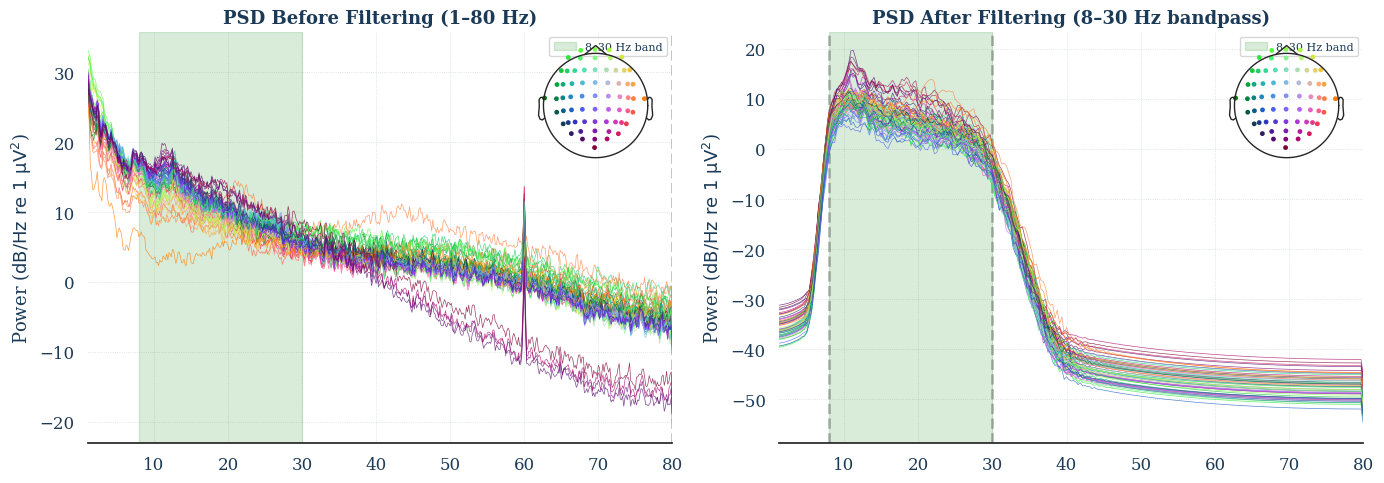

Saved: figures/section2_fig1_psd_comparison.png


In [70]:
# ============================================================
# SECTION 2 — PSD comparison: before vs after filtering
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PSD of raw (unfiltered) data — shows all frequency content
ax = axes[0]
psd_before = raw_before.compute_psd(fmin=1, fmax=80, n_fft=1024)
psd_before.plot(axes=ax, show=False, spatial_colors=True)
ax.set_title('PSD Before Filtering (1–80 Hz)', fontsize=13, fontweight='bold')
ax.axvspan(8, 30, alpha=0.15, color='green', label='8–30 Hz band')
ax.legend(fontsize=8)

# PSD of preprocessed epochs — should show only 8–30 Hz content
ax = axes[1]
psd_after = epochs.compute_psd(method = 'welch', fmin=1, fmax=80, n_fft=512)
psd_after.plot(axes=ax, show=False, spatial_colors=True)
ax.set_title('PSD After Filtering (8–30 Hz bandpass)', fontsize=13, fontweight='bold')
ax.axvspan(8, 30, alpha=0.15, color='green', label='8–30 Hz band')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('figures/section2_fig1_psd_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/section2_fig1_psd_comparison.png")

### 📊 What to look for in this plot:

- **Before filtering (left)**: You should see broadband power including a large 1/f trend
  (power decreasing with frequency), possible 50/60 Hz power line spike, and peaks in the
  alpha/mu (8–12 Hz) range over posterior/central electrodes.
- **After filtering (right)**: Power should be concentrated between 8–30 Hz with sharp
  roll-off at the band edges. No 1/f trend, no power line noise, no slow drift.
- **Green shaded region**: The 8–30 Hz analysis band should encompass all remaining
  spectral power, confirming our bandpass filter is working correctly.
- **If power extends beyond 30 Hz**: The filter order may be too low, or there is
  aliasing from improper resampling (unlikely with MNE's defaults).

In [71]:
print("✅ Section 2 complete — preprocessing pipeline built and applied, epochs extracted")

✅ Section 2 complete — preprocessing pipeline built and applied, epochs extracted


---
## Section 3 — ERD/ERS and Time-Frequency Analysis

### 🔬 Understanding ERD and ERS

**ERD (Event-Related Desynchronization)** is a *decrease* in oscillatory power in a
specific frequency band, relative to a baseline period. In motor imagery:

- When you imagine moving your **right hand**, neurons in the **left motor cortex (C3)**
  become busy processing the motor plan → their rhythmic firing breaks up → **mu and
  beta power drops** (ERD) at C3.
- **C4** (right motor cortex) may show *less* ERD or even a slight *increase* (ERS)
  because it's not involved in right-hand imagery.

**ERD% formula**: `ERD% = (power_task - power_baseline) / power_baseline × 100`
- Negative values = **ERD** (desynchronization — the brain region is active)
- Positive values = **ERS** (synchronization — the brain region is idle/recovering)

**Beta rebound (ERS)**: After motor imagery ends, there is a brief *increase* in beta
(13–30 Hz) power — the motor cortex "resets" to its resting synchronized state.

### 🧭 Contralateral Organization
| Imagined Movement | Active Cortex | Key Electrode | Expected Pattern |
|---|---|---|---|
| Right hand | Left motor cortex | **C3** | Strong ERD (mu + beta) |
| Left hand | Right motor cortex | **C4** | Strong ERD (mu + beta) |

In [ ]:
# ============================================================
# SECTION 3 — Compute ERD/ERS time course for C3 and C4
# ============================================================

def compute_erd(epochs, ch_name, freq_band, baseline_win=(-0.5, 0.0)):
    """
    WHY: ERD/ERS quantifies task-related power changes relative to baseline.
         This is the primary neurophysiological marker for motor imagery decoding.
    WHAT: Bandpass filter → Hilbert transform → instantaneous power → normalize
         to baseline → average across trials → ERD%.
    INPUT:
        epochs      : mne.Epochs — preprocessed EEG epochs
        ch_name     : str — channel name (e.g., 'C3', 'C4')
        freq_band   : tuple(float, float) — (low_freq, high_freq) in Hz
        baseline_win: tuple(float, float) — baseline window in seconds
    OUTPUT:
        erd_percent : np.ndarray, shape (n_timepoints,) — ERD/ERS time course (%)
        times       : np.ndarray, shape (n_timepoints,) — time vector in seconds
    """
    # Need full epochs (including baseline) for proper ERD computation
    # Create epochs with baseline included for this analysis
    sfreq = epochs.info['sfreq']

    # Get channel index
    ch_idx = epochs.ch_names.index(ch_name)

    # Extract single-channel data: (n_epochs, n_timepoints)
    data = epochs.get_data()[:, ch_idx, :]
    times = epochs.times

    # Bandpass filter to the specific frequency band (mu or beta)
    # We use MNE's filter_data for consistency
    data_filtered = mne.filter.filter_data(
        data, sfreq=sfreq,
        l_freq=freq_band[0], h_freq=freq_band[1],
        method='iir',
        iir_params=dict(order=4, ftype='butter')
    )

    # Hilbert transform to get the analytic signal → instantaneous power
    # The envelope (absolute value of analytic signal) squared gives power
    analytic = hilbert(data_filtered, axis=-1)
    power = np.abs(analytic) ** 2  # Instantaneous power: (n_epochs, n_timepoints)

    # Average power across trials
    mean_power = np.mean(power, axis=0)  # (n_timepoints,)

    # Compute baseline power (mean over baseline time window)
    baseline_mask = (times >= baseline_win[0]) & (times <= baseline_win[1])
    if baseline_mask.sum() == 0:
        # If no baseline period in epochs, use first 10% of data
        n_baseline = max(1, int(0.1 * len(times)))
        baseline_power = np.mean(mean_power[:n_baseline])
        print(f"  ⚠️ No baseline period found for {ch_name}; using first {n_baseline} samples")
    else:
        baseline_power = np.mean(mean_power[baseline_mask])

    # ERD% = (task_power - baseline_power) / baseline_power × 100
    # Negative = desynchronization (active), Positive = synchronization (idle)
    erd_percent = (mean_power - baseline_power) / baseline_power * 100

    return erd_percent, times


# We need epochs WITH baseline for proper ERD computation
# Re-epoch with baseline included in the time window
print("Re-epoching with baseline period for ERD analysis...")
events_arr, _ = mne.events_from_annotations(raw, event_id={'T1': 1, 'T2': 2})

# Preprocess raw again for ERD (need the filtered raw, not epochs)
raw_erd = raw.copy()
raw_erd.filter(l_freq=1.0, h_freq=45.0, method='iir',
               iir_params=dict(order=5, ftype='butter'))
raw_erd.set_eeg_reference('average', projection=True)
raw_erd.apply_proj()

# Create epochs including baseline period [-0.5, 4.5]s
epochs_erd = mne.Epochs(
    raw_erd, events_arr,
    event_id={'T1': 1, 'T2': 2},
    tmin=-0.5, tmax=4.5,       # Include 0.5s pre-cue baseline
    baseline=None,              # No baseline correction — we compute ERD% manually
    reject=dict(eeg=150e-6),
    preload=True
)

# Separate left MI (T1) and right MI (T2) epochs
epochs_left = epochs_erd['T1']   # Left fist motor imagery
epochs_right = epochs_erd['T2']  # Right fist motor imagery

print(f"Left MI epochs : {len(epochs_left)}")
print(f"Right MI epochs: {len(epochs_right)}")

In [ ]:
# ============================================================
# SECTION 3 — Plot ERD/ERS 2×2 grid (C3/C4 × Left/Right MI)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)

# Define frequency bands
mu_band = (8, 12)     # Mu rhythm — primary MI marker
beta_band = (13, 30)  # Beta rhythm — secondary MI marker + rebound

# Channels and class epochs
channels = ['C3', 'C4']
class_data = {'Left MI (T1)': epochs_left, 'Right MI (T2)': epochs_right}

for row, ch in enumerate(channels):
    for col, (class_name, ep) in enumerate(class_data.items()):
        ax = axes[row, col]

        # Compute ERD for mu and beta bands
        erd_mu, times = compute_erd(ep, ch, mu_band)
        erd_beta, _ = compute_erd(ep, ch, beta_band)

        # Plot mu (solid line) and beta (dashed line)
        ax.plot(times, erd_mu, color='darkblue', linewidth=2, label=f'Mu ({mu_band[0]}–{mu_band[1]} Hz)')
        ax.plot(times, erd_beta, color='darkred', linewidth=2, linestyle='--', label=f'Beta ({beta_band[0]}–{beta_band[1]} Hz)')

        # Shade ERD (negative = red) and ERS (positive = blue)
        ax.fill_between(times, erd_mu, 0, where=(erd_mu < 0),
                        color='red', alpha=0.15, label='ERD (desynchronization)')
        ax.fill_between(times, erd_mu, 0, where=(erd_mu > 0),
                        color='blue', alpha=0.15, label='ERS (synchronization)')

        # Reference lines
        ax.axhline(0, color='gray', linewidth=0.8, linestyle='-')
        ax.axvline(0, color='black', linewidth=1, linestyle='--', alpha=0.5, label='Cue onset')

        ax.set_title(f'{ch} — {class_name}', fontsize=13, fontweight='bold')
        ax.set_ylabel('ERD/ERS (%)' if col == 0 else '')
        ax.set_xlabel('Time (s)' if row == 1 else '')

        if row == 0 and col == 0:
            ax.legend(fontsize=8, loc='lower left')

fig.suptitle('ERD/ERS Time Course: Mu & Beta Bands at C3/C4', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/section3_fig1_erd_ers.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/section3_fig1_erd_ers.png")

### 📊 What to look for in this plot:

- **Contralateral ERD**: During **right hand MI**, you should see stronger ERD (more
  negative values) at **C3** (left motor cortex) compared to C4. During **left hand MI**,
  the opposite pattern at **C4**.
- **Mu band (solid blue)**: Should show clear ERD starting ~0.5–1s after cue onset,
  reaching maximum depth around 1–2s, then gradually returning to baseline.
- **Beta band (dashed red)**: Similar ERD pattern but typically weaker. May show a
  **beta rebound** (positive ERS) starting ~0.5s after the imagery period ends.
- **Ipsilateral pattern**: The electrode on the same side as the imagined hand may
  show weaker ERD or even slight ERS — the "idling" hemisphere.
- **If patterns are weak or reversed**: This subject may have poor MI performance,
  or the data quality may be low. Real-world BCI performance varies greatly across subjects
  ("BCI illiteracy" affects ~15–30% of users).

In [ ]:
# ============================================================
# SECTION 3 — Morlet wavelet time-frequency analysis
# ============================================================

# Define frequencies for the time-frequency decomposition
freqs = np.arange(4, 41, 1)  # 4 to 40 Hz in 1 Hz steps
n_cycles = freqs / 2.0       # Adaptive cycles: more cycles at higher freq → constant time-frequency trade-off across bands

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for col, (class_name, ep) in enumerate(class_data.items()):
    for row, ch in enumerate(channels):
        ax = axes[row, col]
        ch_idx = ep.ch_names.index(ch)

        # Compute time-frequency representation using Morlet wavelets
        # tfr_morlet returns complex coefficients; we take power (magnitude²)
        power = mne.time_frequency.tfr_morlet(
            ep, freqs=freqs, n_cycles=n_cycles,
            picks=[ch_idx],          # Only compute for the channel of interest
            return_itc=False,        # We only need power, not inter-trial coherence
            average=True             # Average across trials
        )

        # Apply percent baseline correction: (power - baseline) / baseline × 100
        # This normalizes power at each frequency relative to the pre-cue baseline
        power.apply_baseline(baseline=(-0.5, 0.0), mode='percent')

        # Plot the time-frequency map
        power.plot(
            [0], axes=ax, show=False,
            colorbar=True if col == 1 else False,
            title=f'{ch} — {class_name}',
            vmin=-100, vmax=100,     # Symmetric colorbar limits (% baseline)
            cmap='RdBu_r'           # Red = increase, Blue = decrease
        )

        ax.axvline(0, color='black', linewidth=1.5, linestyle='--', alpha=0.7)

fig.suptitle('Time-Frequency Decomposition (Morlet Wavelets, % baseline)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/section3_fig2_tfr.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/section3_fig2_tfr.png")

### 📊 What to look for in this plot:

- **Blue regions (ERD)**: Should appear in the 8–30 Hz range at C3 during right-hand MI
  and at C4 during left-hand MI, starting ~0.5s post-cue.
- **Red regions (ERS)**: May appear as beta rebound (13–30 Hz) after the imagery period,
  or as alpha/mu ERS at the ipsilateral electrode.
- **Temporal evolution**: ERD should onset ~0.5–1s after cue, deepen over 1–2s, and
  persist through the imagery period.
- **Frequency specificity**: ERD should be concentrated in the mu (8–12 Hz) and beta
  (13–30 Hz) bands, not spread across all frequencies.
- **If the map is mostly flat**: The subject may have weak ERD, or the baseline period
  may not be representative.

In [ ]:
# ============================================================
# SECTION 3 — Topographic maps of power difference at key time points
# ============================================================

# Compute TFR for all channels in both classes
print("Computing full-scalp TFR for topographic maps (this may take a minute)...")
power_left = mne.time_frequency.tfr_morlet(
    epochs_left, freqs=freqs, n_cycles=n_cycles,
    return_itc=False, average=True
)
power_left.apply_baseline(baseline=(-0.5, 0.0), mode='percent')

power_right = mne.time_frequency.tfr_morlet(
    epochs_right, freqs=freqs, n_cycles=n_cycles,
    return_itc=False, average=True
)
power_right.apply_baseline(baseline=(-0.5, 0.0), mode='percent')

# Compute LEFT minus RIGHT difference (averaged over 8–30 Hz)
# Positive = more power for left MI; Negative = more power for right MI
# This highlights the lateralized ERD pattern
diff_power = power_left.copy()
diff_power.data = power_left.data - power_right.data

# Select time points for topographic snapshots
time_points = [0.25, 0.5, 1.0, 2.0]  # seconds post-cue

fig, axes = plt.subplots(1, len(time_points), figsize=(16, 4))

for i, t in enumerate(time_points):
    # Plot topomap of the left-minus-right difference, averaged 8–30 Hz
    diff_power.plot_topomap(
        tmin=t - 0.05, tmax=t + 0.05,  # Average ±50ms around target time
        fmin=8, fmax=30,                 # Average over mu+beta range
        axes=axes[i],
        show=False,
        cmap='RdBu_r',                  # Red/Blue diverging colormap
        vlim=(-50, 50),                  # Symmetric limits
        colorbar=True if i == len(time_points) - 1 else False
    )
    axes[i].set_title(f't = {t}s', fontsize=12, fontweight='bold')

fig.suptitle('Left MI − Right MI Power Difference (8–30 Hz) at Key Time Points',
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('figures/section3_fig3_topomaps.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/section3_fig3_topomaps.png")

### 📊 What to look for in this plot:

- **Lateralized pattern over motor cortex**: You should see a clear **left–right
  asymmetry** over the C3/C4 region. Blue at C3 and red at C4 (or vice versa)
  indicates that the two classes produce opposite ERD patterns at the motor cortex.
- **Temporal evolution**: The lateralization should build up over time (weak at 0.25s,
  stronger at 1.0–2.0s) as the motor imagery becomes established.
- **Focal pattern**: The difference should be concentrated over the central/motor
  region, not spread across the entire scalp. Widespread patterns may indicate
  artifacts or non-specific arousal effects.
- **If symmetric (no lateralization)**: The subject may not produce distinguishable
  left vs right MI patterns, which will result in poor classifier accuracy.

In [ ]:
# ============================================================
# SECTION 3 — Cross-dataset validation: ERD/ERS on BCI IV 2a
# ============================================================

print("Loading BCI Competition IV Dataset 2a (MOABB) for cross-dataset ERD validation...")

# Load BCI Competition IV 2a via MOABB (subject 1)
dataset_bci2a = BNCI2014_001()
paradigm = LeftRightImagery()

# Get data for subject 1
X_bci, y_bci, metadata = paradigm.get_data(dataset=dataset_bci2a, subjects=[1])

# MOABB returns data as (n_trials, n_channels, n_timepoints), but we need MNE Epochs
# for the ERD computation. Let's load via MOABB's raw interface instead.
from moabb.datasets import BNCI2014_001
ds = BNCI2014_001()
ds_data = ds.get_data(subjects=[1])

# Get the first session's raw data
subject_sessions = ds_data[1]  # Subject 1
first_session_key = list(subject_sessions.keys())[0]
first_run_key = list(subject_sessions[first_session_key].keys())[0]
raw_bci = subject_sessions[first_session_key][first_run_key]
raw_bci.load_data()

print(f"BCI IV 2a: {len(raw_bci.ch_names)} channels, {raw_bci.info['sfreq']} Hz")

# Find events — MOABB uses standard event codes
events_bci = mne.find_events(raw_bci, shortest_event=1)
event_counts = Counter(events_bci[:, 2])
print(f"Event codes found: {dict(event_counts)}")

# Filter and create epochs for ERD analysis
raw_bci_filt = raw_bci.copy()
raw_bci_filt.filter(l_freq=1.0, h_freq=45.0, method='iir',
                    iir_params=dict(order=5, ftype='butter'))

# Determine left/right event codes (varies by MOABB version)
# Standard: left_hand=1 (769), right_hand=2 (770)
unique_events = np.unique(events_bci[:, 2])
print(f"Unique event codes: {unique_events}")

# Use the paradigm's event mapping
bci_event_id = {'left_hand': 1, 'right_hand': 2}
if 769 in unique_events:
    bci_event_id = {'left_hand': 769, 'right_hand': 770}

# Create epochs
try:
    epochs_bci_erd = mne.Epochs(
        raw_bci_filt, events_bci,
        event_id=bci_event_id,
        tmin=-0.5, tmax=4.5,
        baseline=None,
        reject=dict(eeg=150e-6),
        preload=True,
        on_missing='warn'
    )
except Exception as e:
    print(f"Trying alternative event mapping... ({e})")
    # Auto-detect event codes
    codes = sorted(unique_events)
    if len(codes) >= 2:
        bci_event_id = {'left_hand': codes[0], 'right_hand': codes[1]}
        epochs_bci_erd = mne.Epochs(
            raw_bci_filt, events_bci,
            event_id=bci_event_id,
            tmin=-0.5, tmax=4.5,
            baseline=None,
            reject=dict(eeg=150e-6),
            preload=True,
            on_missing='warn'
        )

print(f"BCI IV 2a epochs: {len(epochs_bci_erd)}")

# Find equivalent of C3/C4 in this dataset
bci_ch_names = epochs_bci_erd.ch_names
print(f"Available channels: {bci_ch_names}")

# BCI IV 2a uses standard 10-20 names: C3, C4 should be present
c3_bci = 'C3' if 'C3' in bci_ch_names else bci_ch_names[7]  # Approximate C3 position
c4_bci = 'C4' if 'C4' in bci_ch_names else bci_ch_names[11] # Approximate C4 position

# Plot ERD for BCI IV 2a
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ep_left_bci = epochs_bci_erd['left_hand']
ep_right_bci = epochs_bci_erd['right_hand']

for col, (ch_bci, ch_label) in enumerate([(c3_bci, 'C3'), (c4_bci, 'C4')]):
    ax = axes[col]

    # Left MI ERD
    erd_left_mu, t = compute_erd(ep_left_bci, ch_bci, mu_band)
    erd_right_mu, _ = compute_erd(ep_right_bci, ch_bci, mu_band)

    ax.plot(t, erd_left_mu, color='blue', linewidth=2, label='Left MI (mu)')
    ax.plot(t, erd_right_mu, color='red', linewidth=2, label='Right MI (mu)')
    ax.axhline(0, color='gray', linewidth=0.8)
    ax.axvline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
    ax.set_title(f'{ch_label} ({ch_bci}) — BCI IV 2a Subject 1', fontsize=13, fontweight='bold')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('ERD/ERS (%)')
    ax.legend(fontsize=10)

fig.suptitle('Cross-Dataset Validation: ERD/ERS on BCI Competition IV 2a',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/section3_fig4_bci2a_erd.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/section3_fig4_bci2a_erd.png")

### 📊 What to look for in this plot:

- **Same contralateral pattern**: Despite being a completely different dataset (different
  subjects, different amplifiers, different sampling rate), the ERD pattern should be
  consistent: stronger ERD at C3 for right-hand MI, stronger at C4 for left-hand MI.
- **Magnitude differences**: BCI IV 2a has only 22 channels (vs 64 in Schalk), so the
  spatial resolution is lower. ERD magnitudes may differ, but the *direction* should match.
- **Cross-dataset consistency**: Consistent ERD patterns across datasets validate that our
  preprocessing pipeline captures genuine neurophysiological signals, not dataset-specific
  artifacts.

In [ ]:
print("✅ Section 3 complete — ERD/ERS and time-frequency analysis validated on two datasets")

---
## Section 4 — Baseline Classifier: CSP + SVM

### 🎯 Common Spatial Patterns (CSP) — Intuitive Explanation

**CSP** finds spatial filters (linear combinations of electrode signals) that
**maximize the variance for one class while minimizing it for the other**
simultaneously.

**Analogy — The camera angle trick:**
Imagine two overlapping clouds of colored points (blue for left MI, red for right MI)
in 3D space. Most camera angles show the clouds mixed together. CSP finds the special
camera angle where the blue and red clouds are maximally separated — one stretched wide,
the other compressed into a narrow line.

**How it works:**
1. Compute the covariance matrix for each class (how channels co-vary across time)
2. Find spatial filters that maximize the ratio: Var(class 1) / Var(class 2)
3. The first few filters maximize class 1 variance; the last few maximize class 2 variance
4. Apply filters → take **log-variance** as features → feed to classifier

**Why log-variance?** CSP features are variance ratios, which are log-normally distributed.
Taking the log transforms them to approximately Gaussian, which is optimal for SVM.

**Why RBF SVM?** The radial basis function kernel implicitly maps features to an
infinite-dimensional space where the classes may be linearly separable, even when they
overlap in the original feature space. With only a few features (4–8 from CSP), SVM
is both fast and effective.

In [ ]:
# ============================================================
# SECTION 4 — Build CSP + SVM pipeline with nested cross-validation
# ============================================================

def run_nested_cv(X, y, epochs_info, n_components=4, n_outer=5, n_inner=3):
    """
    WHY: Nested CV gives an unbiased estimate of generalization performance.
         The outer loop evaluates performance; the inner loop tunes hyperparameters.
         Without nesting, hyperparameter selection biases the accuracy estimate upward.
    WHAT: Outer 5-fold stratified CV × inner 3-fold GridSearchCV over SVM params.
    INPUT:
        X           : np.ndarray, shape (n_epochs, n_channels, n_timepoints)
        y           : np.ndarray, shape (n_epochs,) — binary class labels (0, 1)
        epochs_info : mne.Info — EEG channel info (needed for CSP)
        n_components: int — number of CSP components (pairs of spatial filters)
        n_outer     : int — number of outer CV folds
        n_inner     : int — number of inner CV folds
    OUTPUT:
        results : dict — per-fold metrics, mean/std, best pipeline, and CSP filters
    """
    # Define the ML pipeline: CSP spatial filtering → SVM classifier
    pipe = Pipeline([
        ('csp', CSP(n_components=n_components, log=True, reg=None, norm_trace=True)),
        ('svm', SVC(kernel='rbf', probability=True, random_state=SEED))
    ])

    # Hyperparameter grid for the inner CV
    # C: regularization strength (higher = less regularization)
    # gamma: RBF kernel width (controls decision boundary smoothness)
    param_grid = {
        'svm__C': [0.1, 1, 10, 100],         # Regularization parameter
        'svm__gamma': ['scale', 'auto']        # Kernel coefficient
    }

    # Outer CV: stratified to maintain class balance in each fold
    outer_cv = StratifiedKFold(n_splits=n_outer, shuffle=True, random_state=SEED)

    # Storage for results
    fold_accuracies = []
    fold_f1s = []
    fold_aucs = []
    all_y_true = []
    all_y_pred = []
    all_y_proba = []
    best_score = 0
    best_pipe = None
    best_csp = None

    print(f"Running {n_outer}-fold nested CV (inner {n_inner}-fold GridSearch)...")
    print("-" * 60)

    for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
        # Split data for this outer fold
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Inner CV: grid search over hyperparameters using only training data
        inner_cv = StratifiedKFold(n_splits=n_inner, shuffle=True, random_state=SEED)
        grid_search = GridSearchCV(
            pipe, param_grid,
            cv=inner_cv,
            scoring='accuracy',
            refit=True,          # Refit best model on full training set
            n_jobs=-1            # Use all available cores
        )

        # Fit the grid search (inner CV) on this fold's training data
        grid_search.fit(X_train, y_train)

        # Evaluate on held-out test data
        y_pred = grid_search.predict(X_test)
        y_proba = grid_search.predict_proba(X_test)[:, 1]  # Probability for class 1

        # Compute metrics
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='binary')
        auc = roc_auc_score(y_test, y_proba)

        fold_accuracies.append(acc)
        fold_f1s.append(f1)
        fold_aucs.append(auc)
        all_y_true.extend(y_test)
        all_y_pred.extend(y_pred)
        all_y_proba.extend(y_proba)

        # Track the best pipeline for later analysis
        if acc > best_score:
            best_score = acc
            best_pipe = grid_search.best_estimator_
            best_csp = grid_search.best_estimator_.named_steps['csp']

        print(f"  Fold {fold_idx+1}/{n_outer}: "
              f"Accuracy={acc:.3f}, F1={f1:.3f}, AUC={auc:.3f} "
              f"| Best params: {grid_search.best_params_}")

    print("-" * 60)
    print(f"Mean Accuracy: {np.mean(fold_accuracies):.3f} ± {np.std(fold_accuracies):.3f}")
    print(f"Mean F1 Score: {np.mean(fold_f1s):.3f} ± {np.std(fold_f1s):.3f}")
    print(f"Mean AUC     : {np.mean(fold_aucs):.3f} ± {np.std(fold_aucs):.3f}")

    return {
        'fold_accuracies': fold_accuracies,
        'fold_f1s': fold_f1s,
        'fold_aucs': fold_aucs,
        'mean_accuracy': np.mean(fold_accuracies),
        'std_accuracy': np.std(fold_accuracies),
        'y_true': np.array(all_y_true),
        'y_pred': np.array(all_y_pred),
        'y_proba': np.array(all_y_proba),
        'best_pipeline': best_pipe,
        'best_csp': best_csp
    }

# Run nested CV on subject S001
results_s001 = run_nested_cv(X, y, epochs.info)

In [ ]:
# ============================================================
# SECTION 4 — Plot CSP spatial filters as topomaps
# ============================================================

# CSP filters show which electrode combinations the algorithm found most useful.
# The first and last filters are the most informative (maximize/minimize class ratio).

csp = results_s001['best_csp']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# CSP patterns (not filters) — represent the scalp distribution of each component
# Patterns are easier to interpret neurophysiologically than filters
for i, ax in enumerate(axes):
    # Get the i-th CSP pattern
    pattern = csp.patterns_[i]

    # Create an MNE Evoked object for topomap plotting
    evoked = mne.EvokedArray(pattern.reshape(-1, 1), epochs.info, tmin=0)
    evoked.plot_topomap(
        times=[0], axes=ax, show=False,
        colorbar=False,
        cmap='RdBu_r',
        scalings=1    # Raw pattern values, no scaling
    )
    ax.set_title(f'CSP Pattern {i+1}', fontsize=12, fontweight='bold')

fig.suptitle('CSP Spatial Patterns (Filters that separate Left vs Right MI)',
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('figures/section4_fig1_csp_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/section4_fig1_csp_patterns.png")

### 📊 What to look for in this plot:

- **Patterns 1–2** (leftmost): Should show strong activation focused on one side of the
  motor cortex (e.g., around C3 or C4). These maximize variance for one class.
- **Patterns 3–4** (rightmost): Should show the complementary pattern on the opposite
  side — maximizing variance for the other class.
- **Focal motor cortex activation**: Good CSP patterns are focal, centered around
  C3/C4/Cz. Diffuse or noisy patterns may indicate poor data quality.
- **Symmetry**: The first and last patterns should be roughly mirror images of each
  other across the midline, reflecting the contralateral organization of motor imagery.
- **If patterns look noisy/scattered**: May indicate too few trials, bad channels, or
  weak MI signals for this subject.

In [ ]:
# ============================================================
# SECTION 4 — Sliding window classification (accuracy vs time)
# ============================================================

def sliding_window_accuracy(X_full, y, epochs_info, win_size=0.5, step_size=0.25, sfreq=160):
    """
    WHY: Shows WHEN during the trial the signal becomes discriminable, confirming
         that classification is based on task-related activity (not pre-cue noise).
    WHAT: Slide a time window across the trial, classify at each position, report accuracy.
    INPUT:
        X_full     : np.ndarray, shape (n_epochs, n_channels, n_timepoints)
        y          : np.ndarray, shape (n_epochs,) — class labels
        epochs_info: mne.Info — channel info
        win_size   : float — window size in seconds
        step_size  : float — step size in seconds
        sfreq      : float — sampling frequency
    OUTPUT:
        times_center : list of float — center time of each window (seconds)
        accuracies   : list of float — mean CV accuracy at each window
    """
    n_samples = X_full.shape[2]
    win_samples = int(win_size * sfreq)    # Window size in samples
    step_samples = int(step_size * sfreq)  # Step size in samples

    times_center = []    # Center time of each window
    accuracies = []      # Accuracy at each window position

    # Slide window across the trial
    start = 0
    while start + win_samples <= n_samples:
        # Extract data in current window
        X_win = X_full[:, :, start:start + win_samples]

        # Center time (in seconds) for this window
        t_center = float(start + win_samples / 2) / sfreq  # Convert sample index to time (seconds)
        times_center.append(t_center)

        # Quick 3-fold CV with CSP + SVM (no inner tuning for speed)
        pipe = Pipeline([
            ('csp', CSP(n_components=4, log=True, reg=None, norm_trace=True)),
            ('svm', SVC(kernel='rbf', C=1, gamma='scale', random_state=SEED))
        ])
        cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

        fold_accs = []
        for train_idx, test_idx in cv.split(X_win, y):
            pipe.fit(X_win[train_idx], y[train_idx])
            fold_accs.append(pipe.score(X_win[test_idx], y[test_idx]))

        accuracies.append(np.mean(fold_accs))
        start += step_samples

    return times_center, accuracies

print("Running sliding window classification (this may take a minute)...")
times_sw, accs_sw = sliding_window_accuracy(X, y, epochs.info, sfreq=epochs.info['sfreq'])

# Plot accuracy vs time
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(times_sw, accs_sw, 'b-o', linewidth=2, markersize=5, label='CSP+SVM accuracy')
ax.axhline(0.5, color='red', linewidth=1.5, linestyle='--', label='Chance level (50%)')
ax.fill_between(times_sw, 0.5, accs_sw,
                where=[a > 0.5 for a in accs_sw],
                alpha=0.2, color='green', label='Above chance')
ax.set_xlabel('Time from epoch start (s)', fontsize=12)
ax.set_ylabel('Classification Accuracy', fontsize=12)
ax.set_title('Sliding Window Classification — When Does the Signal Become Discriminable?',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0.35, 0.85)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/section4_fig2_sliding_window.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/section4_fig2_sliding_window.png")

### 📊 What to look for in this plot:

- **Chance level at start**: At the very beginning of the epoch (near 0.5s post-cue),
  accuracy should be close to 50% (chance for 2 classes) because the motor imagery
  has barely started.
- **Rising accuracy**: Accuracy should increase over time, reaching its peak around
  1–2 seconds into the epoch as the ERD pattern becomes fully established.
- **Sustained accuracy**: Good subjects maintain above-chance accuracy throughout the
  imagery period (up to 4.5s).
- **Peak timing matches ERD**: The accuracy peak should coincide with the strongest
  ERD observed in Section 3 — confirming that the classifier is using the correct
  neurophysiological signal.
- **If accuracy is at or below chance throughout**: This subject may have weak MI
  signals ("BCI illiteracy"), or there may be preprocessing issues.

In [ ]:
# ============================================================
# SECTION 4 — Multi-subject analysis (S001–S020)
# ============================================================

def process_subject(subject_id):
    """
    WHY: Evaluate the pipeline across multiple subjects to assess robustness.
         BCI performance varies greatly between individuals (~15–30% are 'BCI illiterate').
    WHAT: Load, preprocess, and classify one subject's data end-to-end.
    INPUT:
        subject_id : int — subject number (1–109)
    OUTPUT:
        accuracy : float or None — mean CV accuracy (None if processing fails)
    """
    try:
        # Load this subject's MI runs
        raw_subj = load_schalk_subject(subject_id=subject_id, runs=[4, 8, 12])

        # Preprocess
        epochs_subj = preprocess_raw(raw_subj)

        # Extract arrays
        X_subj = epochs_subj.get_data()
        y_subj = epochs_subj.events[:, 2] - 1  # Remap to 0/1

        # Check minimum trial count per class
        class_counts = Counter(y_subj)
        if min(class_counts.values()) < 5:
            print(f"  ⚠️ Subject {subject_id:03d}: Too few trials ({class_counts}), skipping")
            return None

        # Quick 5-fold CV (no inner grid search for speed)
        pipe = Pipeline([
            ('csp', CSP(n_components=4, log=True, reg=None, norm_trace=True)),
            ('svm', SVC(kernel='rbf', C=1, gamma='scale', random_state=SEED))
        ])
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

        fold_accs = []
        for train_idx, test_idx in cv.split(X_subj, y_subj):
            pipe.fit(X_subj[train_idx], y_subj[train_idx])
            fold_accs.append(pipe.score(X_subj[test_idx], y_subj[test_idx]))

        mean_acc = np.mean(fold_accs)
        print(f"  Subject S{subject_id:03d}: Accuracy = {mean_acc:.3f}")
        return mean_acc

    except Exception as e:
        print(f"  ⚠️ Subject {subject_id:03d} failed: {e}")
        return None

# Run on subjects S001–S020
print("=" * 60)
print("Multi-subject analysis: S001–S020")
print("=" * 60)

subject_accuracies_csp = {}

for sid in range(1, 21):
    print(f"\nProcessing subject S{sid:03d}...")
    acc = process_subject(sid)
    if acc is not None:
        subject_accuracies_csp[f'S{sid:03d}'] = acc

print(f"\nProcessed {len(subject_accuracies_csp)} subjects successfully")
print(f"Mean accuracy across subjects: {np.mean(list(subject_accuracies_csp.values())):.3f} "
      f"± {np.std(list(subject_accuracies_csp.values())):.3f}")

In [ ]:
# ============================================================
# SECTION 4 — Per-subject accuracy bar chart
# ============================================================

fig, ax = plt.subplots(figsize=(14, 6))

subjects = list(subject_accuracies_csp.keys())
accuracies = list(subject_accuracies_csp.values())

# Color bars: green if above chance (0.5), red otherwise
colors = ['#2ecc71' if a > 0.5 else '#e74c3c' for a in accuracies]

bars = ax.bar(subjects, accuracies, color=colors, edgecolor='black', linewidth=0.5)

# Add accuracy values on top of bars
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{acc:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Reference lines
ax.axhline(0.5, color='red', linewidth=1.5, linestyle='--', label='Chance level (50%)')
mean_acc = np.mean(accuracies)
ax.axhline(mean_acc, color='blue', linewidth=1.5, linestyle=':', label=f'Mean ({mean_acc:.2f})')

ax.set_xlabel('Subject', fontsize=12)
ax.set_ylabel('Classification Accuracy', fontsize=12)
ax.set_title('Per-Subject CSP+SVM Accuracy (Schalk Dataset)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0.3, 1.0)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('figures/section4_fig3_subject_accuracies.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/section4_fig3_subject_accuracies.png")

### 📊 What to look for in this plot:

- **Inter-subject variability**: BCI performance varies widely. Expect accuracies ranging
  from ~50% (chance) to ~85%+. This is normal and reflects the "BCI illiteracy" phenomenon.
- **Above-chance subjects**: Most subjects (>70%) should have accuracy above 50%. Subjects
  with strong motor imagery produce clear ERD patterns.
- **Below-chance outliers**: Subjects near or below 50% may have difficulty performing MI,
  noisy recordings, or the paradigm may not suit their cognitive style.
- **Mean accuracy**: For a CSP+SVM baseline on motor imagery, 60–75% average across
  subjects is typical. Higher with deep learning or advanced features.
- **Green vs Red bars**: Quickly identifies which subjects are "BCI literate" (green)
  vs struggling (red).

In [ ]:
# ============================================================
# SECTION 4 — Confusion matrix and ROC for best subject
# ============================================================

# Find the best-performing subject
best_subj = max(subject_accuracies_csp, key=subject_accuracies_csp.get)
print(f"Best subject: {best_subj} with accuracy {subject_accuracies_csp[best_subj]:.3f}")

# Re-run full nested CV on best subject for detailed analysis
print(f"\nRe-running nested CV on {best_subj} for confusion matrix and ROC...")
best_sid = int(best_subj[1:])
raw_best = load_schalk_subject(subject_id=best_sid, runs=[4, 8, 12])
epochs_best = preprocess_raw(raw_best)
X_best = epochs_best.get_data()
y_best = epochs_best.events[:, 2] - 1

results_best = run_nested_cv(X_best, y_best, epochs_best.info)

# --- Confusion Matrix ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Normalized confusion matrix (proportions)
cm = confusion_matrix(results_best['y_true'], results_best['y_pred'], normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['Left MI', 'Right MI'],
            yticklabels=['Left MI', 'Right MI'],
            ax=axes[0], cbar_kws={'label': 'Proportion'},
            annot_kws={'size': 16})
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('True', fontsize=12)
axes[0].set_title(f'Confusion Matrix — {best_subj} (Normalized)', fontsize=13, fontweight='bold')

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(results_best['y_true'], results_best['y_proba'])
roc_auc = roc_auc_score(results_best['y_true'], results_best['y_proba'])

axes[1].plot(fpr, tpr, 'b-', linewidth=2.5, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Chance (AUC = 0.5)')
axes[1].fill_between(fpr, 0, tpr, alpha=0.15, color='blue')
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title(f'ROC Curve — {best_subj}', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=12)
axes[1].set_aspect('equal')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/section4_fig4_cm_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/section4_fig4_cm_roc.png")

### 📊 What to look for in this plot:

- **Confusion matrix diagonals**: High values (>0.7) on the diagonal indicate good
  classification. Off-diagonal values show misclassification rates.
- **Balanced errors**: If one class is consistently misclassified more than the other,
  there may be a class imbalance issue or one MI direction produces weaker ERD.
- **ROC curve**: Should bow toward the upper-left corner. AUC > 0.7 is reasonable;
  AUC > 0.8 is good; AUC > 0.9 is excellent for EEG BCI.
- **AUC vs Accuracy**: AUC is threshold-independent and more informative than accuracy
  for imbalanced datasets. They should tell a consistent story.

In [ ]:
# ============================================================
# SECTION 4 — Cross-dataset validation on BCI Competition IV 2a
# ============================================================

print("=" * 60)
print("Cross-dataset validation: BCI Competition IV 2a (9 subjects)")
print("=" * 60)

subject_accuracies_csp_bci2a = {}

# Load BCI IV 2a data through MOABB paradigm interface
dataset_bci2a = BNCI2014_001()
paradigm = LeftRightImagery()

for subj_id in range(1, 10):  # 9 subjects
    print(f"\nProcessing BCI IV 2a Subject {subj_id}...")
    try:
        # MOABB returns (n_trials, n_channels, n_timepoints), labels, metadata
        X_bci, y_bci, meta = paradigm.get_data(dataset=dataset_bci2a, subjects=[subj_id])

        # Encode labels as integers
        label_map = {label: idx for idx, label in enumerate(sorted(np.unique(y_bci)))}
        y_bci_int = np.array([label_map[l] for l in y_bci])

        print(f"  Shape: {X_bci.shape}, Classes: {Counter(y_bci_int)}")

        # Run 5-fold CV with CSP + SVM
        pipe = Pipeline([
            ('csp', CSP(n_components=4, log=True, reg=None, norm_trace=True)),
            ('svm', SVC(kernel='rbf', C=1, gamma='scale', random_state=SEED))
        ])
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

        fold_accs = []
        for train_idx, test_idx in cv.split(X_bci, y_bci_int):
            pipe.fit(X_bci[train_idx], y_bci_int[train_idx])
            fold_accs.append(pipe.score(X_bci[test_idx], y_bci_int[test_idx]))

        mean_acc = np.mean(fold_accs)
        subject_accuracies_csp_bci2a[f'BCI2a_S{subj_id:02d}'] = mean_acc
        print(f"  Subject {subj_id}: Accuracy = {mean_acc:.3f}")

    except Exception as e:
        print(f"  ⚠️ Subject {subj_id} failed: {e}")

print(f"\nBCI IV 2a — {len(subject_accuracies_csp_bci2a)} subjects processed")
if subject_accuracies_csp_bci2a:
    bci_accs = list(subject_accuracies_csp_bci2a.values())
    print(f"Mean accuracy: {np.mean(bci_accs):.3f} ± {np.std(bci_accs):.3f}")

In [ ]:
# ============================================================
# SECTION 4 — BCI IV 2a per-subject accuracy bar chart
# ============================================================

if subject_accuracies_csp_bci2a:
    fig, ax = plt.subplots(figsize=(12, 5))

    subjects_bci = list(subject_accuracies_csp_bci2a.keys())
    accs_bci = list(subject_accuracies_csp_bci2a.values())
    colors_bci = ['#2ecc71' if a > 0.5 else '#e74c3c' for a in accs_bci]

    bars = ax.bar(subjects_bci, accs_bci, color=colors_bci, edgecolor='black', linewidth=0.5)

    for bar, acc in zip(bars, accs_bci):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{acc:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.axhline(0.5, color='red', linewidth=1.5, linestyle='--', label='Chance level (50%)')
    mean_bci = np.mean(accs_bci)
    ax.axhline(mean_bci, color='blue', linewidth=1.5, linestyle=':', label=f'Mean ({mean_bci:.2f})')

    ax.set_xlabel('Subject', fontsize=12)
    ax.set_ylabel('Classification Accuracy', fontsize=12)
    ax.set_title('Per-Subject CSP+SVM Accuracy — BCI Competition IV 2a', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.set_ylim(0.3, 1.0)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('figures/section4_fig5_bci2a_accuracies.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: figures/section4_fig5_bci2a_accuracies.png")
else:
    print("No BCI IV 2a results to plot.")

### 📊 What to look for in this plot:

- **Cross-dataset consistency**: If the CSP+SVM pipeline achieves similar accuracy
  ranges on BCI IV 2a as on the Schalk dataset, this validates that our approach
  captures genuine MI neural patterns, not dataset-specific artifacts.
- **BCI IV 2a typically shows higher accuracy**: This dataset was recorded in a
  controlled lab setting with high-quality amplifiers and well-trained subjects,
  so expect slightly higher accuracies (65–85% range).
- **Subject variability**: Same inter-subject variability pattern should be visible.
  Some subjects excel, others are near chance — this is the fundamental challenge
  of BCI research.

In [ ]:
# ============================================================
# SECTION 4 — Summary comparison table
# ============================================================

# Create summary DataFrame
summary_data = []

# Schalk results
if subject_accuracies_csp:
    schalk_accs = list(subject_accuracies_csp.values())
    summary_data.append({
        'Dataset': 'Schalk (PhysioNet)',
        'N Subjects': len(subject_accuracies_csp),
        'Mean Accuracy': f'{np.mean(schalk_accs):.3f} ± {np.std(schalk_accs):.3f}',
        'Min Accuracy': f'{np.min(schalk_accs):.3f}',
        'Max Accuracy': f'{np.max(schalk_accs):.3f}',
        'Above Chance': f'{sum(a > 0.5 for a in schalk_accs)}/{len(schalk_accs)}'
    })

# BCI IV 2a results
if subject_accuracies_csp_bci2a:
    bci_accs = list(subject_accuracies_csp_bci2a.values())
    summary_data.append({
        'Dataset': 'BCI IV 2a (MOABB)',
        'N Subjects': len(subject_accuracies_csp_bci2a),
        'Mean Accuracy': f'{np.mean(bci_accs):.3f} ± {np.std(bci_accs):.3f}',
        'Min Accuracy': f'{np.min(bci_accs):.3f}',
        'Max Accuracy': f'{np.max(bci_accs):.3f}',
        'Above Chance': f'{sum(a > 0.5 for a in bci_accs)}/{len(bci_accs)}'
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + "=" * 70)
print("CROSS-DATASET SUMMARY — CSP + SVM Baseline")
print("=" * 70)
print(summary_df.to_string(index=False))
print("=" * 70)

print()
print("✅ Section 4 complete — CSP+SVM baseline validated on two datasets")
print(f"   Schalk: {len(subject_accuracies_csp)} subjects analyzed")
print(f"   BCI IV 2a: {len(subject_accuracies_csp_bci2a)} subjects analyzed")